# American Express — Default Prediction: Exploratory Data Analysis

This notebook explores the AMEX default-prediction dataset to understand its
structure before modelling. Because the raw `train_data.csv` is **15.6 GB**,
all exploration here is done on a **sample** (the first ~1M statement rows) plus
the full 30 MB labels file.

**Key questions**
1. How balanced is the target (default vs non-default)?
2. How many monthly statements does each customer have?
3. How much data is missing, and where?
4. What are the feature groups (B/D/P/R/S)?
5. Does a key feature (`P_2`) separate the classes?

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import config

SAMPLE_ROWS = 600_000

## 1. Target distribution (full labels)

In [2]:
labels = pd.read_csv(config.TRAIN_LABELS_CSV)
print(f'Customers: {len(labels):,}')
print(f'Default rate: {labels.target.mean():.4f}')
labels.target.value_counts(normalize=True)

Customers: 458,913
Default rate: 0.2589


target
0    0.741066
1    0.258934
Name: proportion, dtype: float64

~458K customers with a **~26% default rate** — imbalanced but not extreme.
Note the competition metric weights the negative class ×20 to undo a 5%
down-sampling of negatives in the *public* data.

## 2. Load a sample of statements

In [3]:
df = pd.read_csv(config.TRAIN_CSV, nrows=SAMPLE_ROWS)
df[config.DATE_COL] = pd.to_datetime(df[config.DATE_COL])
feat_cols = [c for c in df.columns if c not in config.NON_FEATURE_COLS]
print(df.shape, '|', len(feat_cols), 'features')
print('Date range:', df[config.DATE_COL].min(), '->', df[config.DATE_COL].max())
df.head()

(600000, 190) | 188 features
Date range: 2017-03-01 00:00:00 -> 2018-03-31 00:00:00


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827


## 3. Statements per customer

count    49752.000000
mean        12.059817
std          2.589982
min          1.000000
25%         13.000000
50%         13.000000
75%         13.000000
max         13.000000
dtype: float64


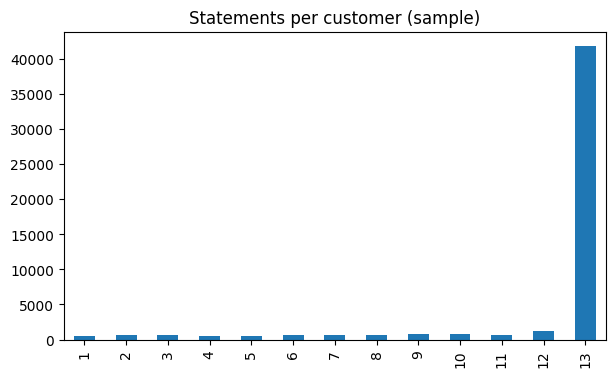

In [4]:
spc = df.groupby(config.ID_COL).size()
print(spc.describe())
spc.value_counts().sort_index().plot(kind='bar', figsize=(7,4),
    title='Statements per customer (sample)'); plt.show()

Most customers have the **full 13 monthly statements**, but a meaningful tail
has fewer. This motivates aggregating each customer's series into fixed-length
summary features (mean/std/min/max/last) plus a `statement_count` feature.

## 4. Missingness

In [5]:
miss = df[feat_cols].isna().mean().sort_values(ascending=False)
print('Features >50% missing:', (miss > 0.5).sum())
miss.head(15)

Features >50% missing: 30


D_87     0.999438
D_88     0.998803
D_108    0.994678
D_110    0.994008
D_111    0.994008
B_39     0.993578
D_73     0.989645
B_42     0.987653
D_137    0.964508
D_138    0.964508
D_135    0.964508
D_136    0.964508
D_134    0.964508
R_9      0.942200
B_29     0.930568
dtype: float64

~30 features are >50% missing (some ~99.9%). Gradient-boosted trees handle
NaNs natively, so we keep them rather than impute.

## 5. Feature groups & categorical features

In [6]:
groups = pd.Series([c.split('_')[0] for c in feat_cols]).value_counts()
print('Feature counts by prefix:\n', groups)
print('\nDeclared categoricals present:',
      [c for c in config.CATEGORICAL_FEATURES if c in df.columns])

Feature counts by prefix:
 D    96
B    40
R    28
S    21
P     3
Name: count, dtype: int64

Declared categoricals present: ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']


Prefixes: **D**elinquency (96), **B**alance (40), **R**isk (28), **S**pend (21),
**P**ayment (3). Eleven features are categorical; `D_63`/`D_64` are strings.

## 6. Does `P_2` separate defaulters? (last statement value)

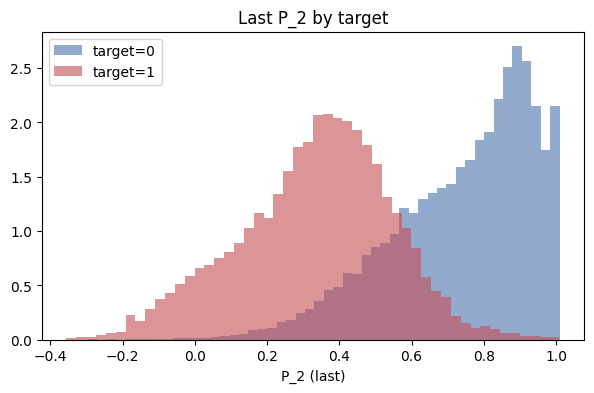

In [7]:
last = df.sort_values(config.DATE_COL).groupby(config.ID_COL)['P_2'].last()
m = last.to_frame('P_2_last').merge(labels.set_index(config.ID_COL),
                                    left_index=True, right_index=True)
fig, ax = plt.subplots(figsize=(7,4))
for t, c in [(0,'#4C72B0'), (1,'#C44E52')]:
    ax.hist(m.loc[m.target==t,'P_2_last'].dropna(), bins=50, alpha=0.6,
            density=True, color=c, label=f'target={t}')
ax.set_title('Last P_2 by target'); ax.set_xlabel('P_2 (last)'); ax.legend(); plt.show()

`P_2` (a payment feature) clearly separates the classes — low last-`P_2`
customers default far more often. It is consistently the **single most
important feature** in the trained model (see `outputs/feature_importance.csv`).

---
## Takeaways for modelling
- Collapse each customer's ≤13 statements into summary stats (mean/std/min/max/**last**).
- `last`-value features are especially predictive (most recent state of the account).
- Keep NaNs; let LightGBM split on them.
- Optimize/early-stop on the **official AMEX metric**, not log-loss.
- See `src/feature_engineering.py` and `src/train_baseline.py` for the implementation.